In [3]:
import pandas as pd
from pathlib import Path

# notebooks/ klasöründesin, o yüzden ../ ile repo köküne çıkıyoruz
train_path = Path("../data/raw/CMAPSSData/train_FD001.txt")
assert train_path.exists(), f"File not found: {train_path}"

# FD001 dosyaları boşlukla ayrılmış, header yok
df = pd.read_csv(train_path, sep=r"\s+", header=None)

# Kolon isimleri: engine_id, cycle, 3 setting, 21 sensor
cols = (
    ["engine_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"s{i}" for i in range(1, 22)]
)
df.columns = cols

print("Shape:", df.shape)
df.head()

Shape: (20631, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print("Unique engines:", df["engine_id"].nunique())
print("Engine id range:", df["engine_id"].min(), "-", df["engine_id"].max())

per_engine = df.groupby("engine_id")["cycle"].agg(["min", "max"])
print("First 5 engines cycle min/max:")
display(per_engine.head())

print("Any non-positive cycles?", (df["cycle"] <= 0).any())

Unique engines: 100
Engine id range: 1 - 100
First 5 engines cycle min/max:


,min,max
engine_id,,
1,1,192
2,1,287
3,1,179
4,1,189
5,1,269


Any non-positive cycles? False


In [5]:
print("Shape:", df.shape)
print("Unique engines:", df["engine_id"].nunique())
print("Engine id range:", df["engine_id"].min(), "-", df["engine_id"].max())

per_engine = df.groupby("engine_id")["cycle"].agg(["min", "max"])
print("First 5 engines cycle min/max:")
per_engine.head()


Shape: (20631, 26)
Unique engines: 100
Engine id range: 1 - 100
First 5 engines cycle min/max:


,min,max
engine_id,,
1,1,192
2,1,287
3,1,179
4,1,189
5,1,269


In [8]:
import pandas as pd

# Her motorun toplam ömrü = o motorun gördüğü en büyük cycle
engine_life = df.groupby("engine_id")["cycle"].max().sort_values()

print("Motor sayısı:", engine_life.shape[0])
print("Min ömür (cycle):", engine_life.min())
print("Median ömür (cycle):", int(engine_life.median()))
print("Max ömür (cycle):", engine_life.max())

engine_life.head(), engine_life.tail()


Motor sayısı: 100
Min ömür (cycle): 128
Median ömür (cycle): 199
Max ömür (cycle): 362


(engine_id
 39    128
 91    135
 70    137
 57    137
 58    147
 Name: cycle, dtype: int64,
 engine_id
 83    293
 67    313
 96    336
 92    341
 69    362
 Name: cycle, dtype: int64)

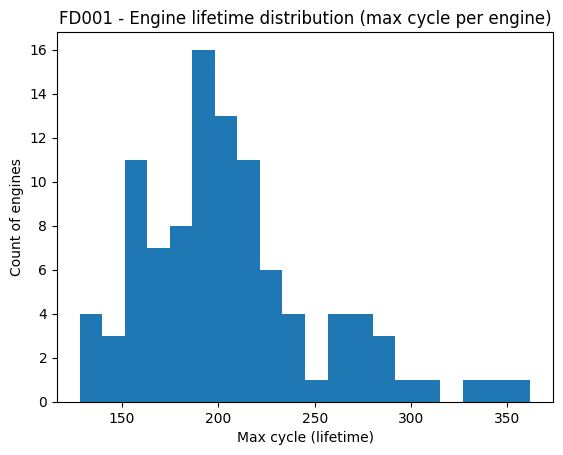

In [9]:
import matplotlib.pyplot as plt

engine_life.plot(kind="hist", bins=20)
plt.title("FD001 - Engine lifetime distribution (max cycle per engine)")
plt.xlabel("Max cycle (lifetime)")
plt.ylabel("Count of engines")
plt.show()


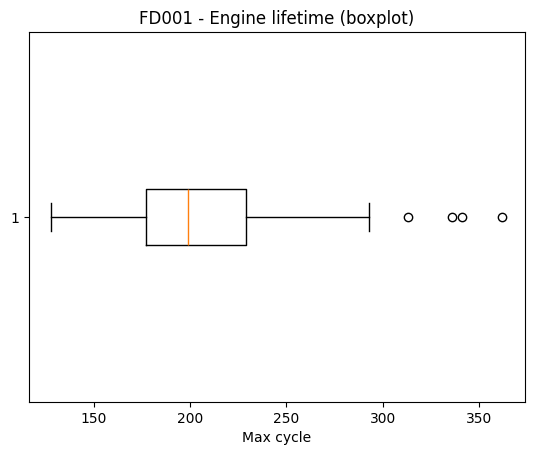

In [10]:
plt.figure()
plt.boxplot(engine_life.values, vert=False)
plt.title("FD001 - Engine lifetime (boxplot)")
plt.xlabel("Max cycle")
plt.show()


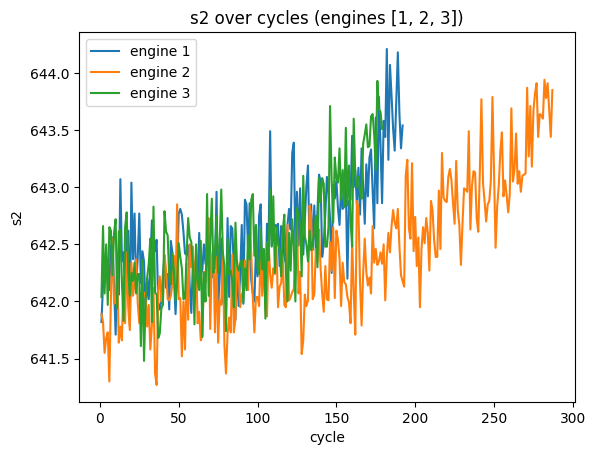

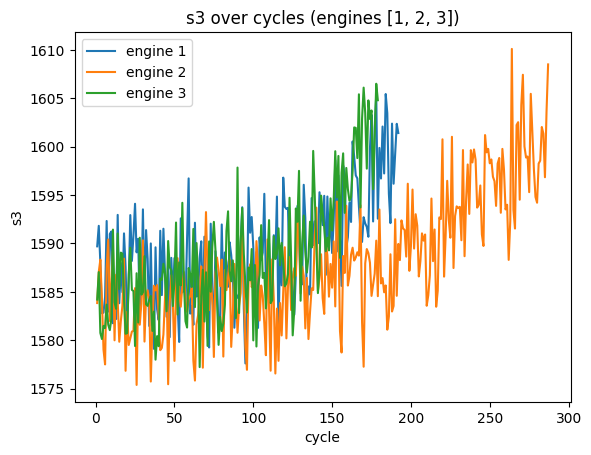

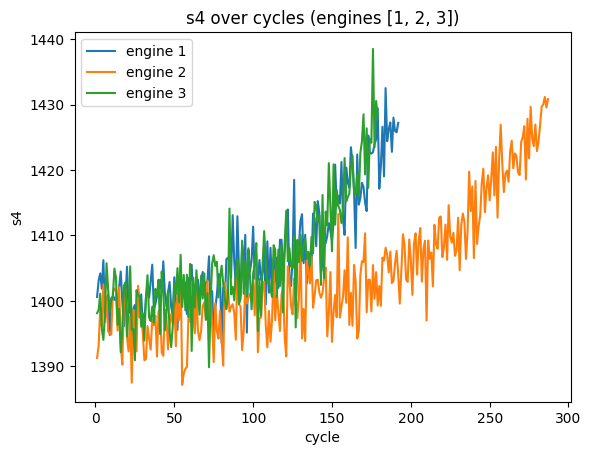

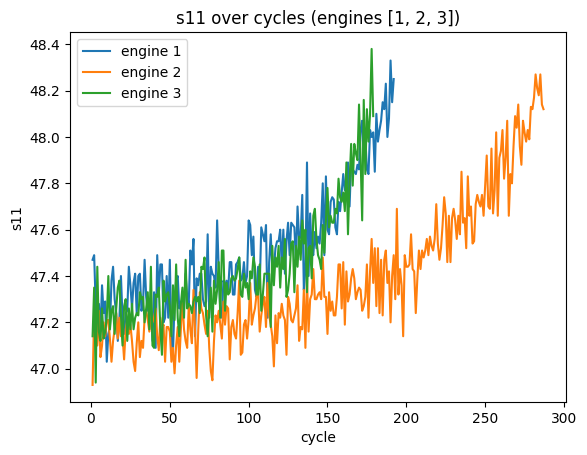

In [11]:
import matplotlib.pyplot as plt

engines = [1, 2, 3]                 # sadece 3 motor
sensors = ["s2", "s3", "s4", "s11"]  # örnek 4 sensör (istersen değiştirebiliriz)

for s in sensors:
    plt.figure()
    for e in engines:
        sub = df[df["engine_id"] == e]
        plt.plot(sub["cycle"], sub[s], label=f"engine {e}")
    plt.title(f"{s} over cycles (engines {engines})")
    plt.xlabel("cycle")
    plt.ylabel(s)
    plt.legend()
    plt.show()


/var/folders/gg/3khq35r52z56y6c1cg0np9xh0000gn/T/ipykernel_72832/474646339.py:43: RuntimeWarning: All-NaN slice encountered
  "trend_slope_pct": float((slope_abs > np.nanmedian(slope_abs)).mean()),  # kaba: “daha trendli yarısı”
/var/folders/gg/3khq35r52z56y6c1cg0np9xh0000gn/T/ipykernel_72832/474646339.py:45: RuntimeWarning: All-NaN slice encountered
  "median_abs_slope": float(np.nanmedian(slope_abs)),
/var/folders/gg/3khq35r52z56y6c1cg0np9xh0000gn/T/ipykernel_72832/474646339.py:46: RuntimeWarning: All-NaN slice encountered
  "median_abs_corr": float(np.nanmedian(corr_abs)),


,sensor,engines,low_var_eng_pct,trend_slope_pct,corr_gt_0.3_pct,median_abs_slope,median_abs_corr,global_std
13,s11,100,0.0,0.5,1.0,0.003335,0.816341,0.267087
14,s12,100,0.0,0.5,1.0,0.008454,0.810574,0.737553
6,s4,100,0.0,0.5,1.0,0.109292,0.790356,9.000605
9,s7,100,0.0,0.5,1.0,0.009910,0.783062,0.885092
17,s15,100,0.0,0.5,1.0,0.000427,0.734957,0.037505
23,s21,100,0.0,0.5,1.0,0.001221,0.730344,0.108251
22,s20,100,0.0,0.5,1.0,0.002015,0.717382,0.180746
4,s2,100,0.0,0.5,1.0,0.005301,0.682972,0.500053
19,s17,100,0.0,0.5,1.0,0.016975,0.680630,1.548763
5,s3,100,0.0,0.5,1.0,0.065096,0.654014,6.131150


In [13]:
import numpy as np
import pandas as pd

# --- yardımcı: hepsi NaN ise 0 dön (warning'leri keser) ---
def safe_nanmedian(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmedian(x)) if np.isfinite(x).any() else 0.0

# --- sensör bazında motor-level özet metrikleri çıkar ---
def summarize_sensor(df, sensor_col):
    rows = []
    for eid, g in df.groupby("engine_id"):
        x = g["cycle"].to_numpy(dtype=float)
        y = g[sensor_col].to_numpy(dtype=float)

        std_engine = float(np.std(y))
        slope = np.nan
        corr = np.nan

        # slope ve corr için en az 2 nokta ve sıfır varyans olmaması lazım
        if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
            slope = float(np.polyfit(x, y, 1)[0])     # basit lineer trend eğimi
            corr  = float(np.corrcoef(x, y)[0, 1])    # cycle ile korelasyon

        rows.append({
            "engine_id": int(eid),
            "std_engine": std_engine,
            "slope": slope,
            "corr": corr,
        })
    return pd.DataFrame(rows)

# --- hangi kolonlar sensör? (s1..s21) ---
sensor_cols = [c for c in df.columns if c.startswith("s")]

# --- tüm sensörler için summary tablosu ---
summary_rows = []
for s in sensor_cols:
    per = summarize_sensor(df, s)
    slope_abs = per["slope"].abs()
    corr_abs  = per["corr"].abs()

    summary_rows.append({
        "sensor": s,
        "engines": int(per["engine_id"].nunique()),
        # çok düşük varyanslı motor oranı (eşiği istersen sonra ayarlarız)
        "low_var_eng_pct": float((per["std_engine"] < 1e-3).mean()),
        # cycle ile anlamlı ilişki gösteren motor oranı
        "corr_gt_0.3_pct": float((corr_abs > 0.3).mean()),
        # NaN-safe medyan metrikler
        "median_abs_slope": safe_nanmedian(slope_abs),
        "median_abs_corr":  safe_nanmedian(corr_abs),
        # tüm dataset genelinde standart sapma (kabaca global varyans)
        "global_std": float(df[s].std()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["corr_gt_0.3_pct", "median_abs_corr", "global_std"],
    ascending=False
)

summary_df.head(10)


,sensor,engines,low_var_eng_pct,corr_gt_0.3_pct,median_abs_slope,median_abs_corr,global_std
13,s11,100,0.0,1.0,0.003335,0.816341,0.267087
14,s12,100,0.0,1.0,0.008454,0.810574,0.737553
6,s4,100,0.0,1.0,0.109292,0.790356,9.000605
9,s7,100,0.0,1.0,0.009910,0.783062,0.885092
17,s15,100,0.0,1.0,0.000427,0.734957,0.037505
23,s21,100,0.0,1.0,0.001221,0.730344,0.108251
22,s20,100,0.0,1.0,0.002015,0.717382,0.180746
4,s2,100,0.0,1.0,0.005301,0.682972,0.500053
19,s17,100,0.0,1.0,0.016975,0.680630,1.548763
5,s3,100,0.0,1.0,0.065096,0.654014,6.131150


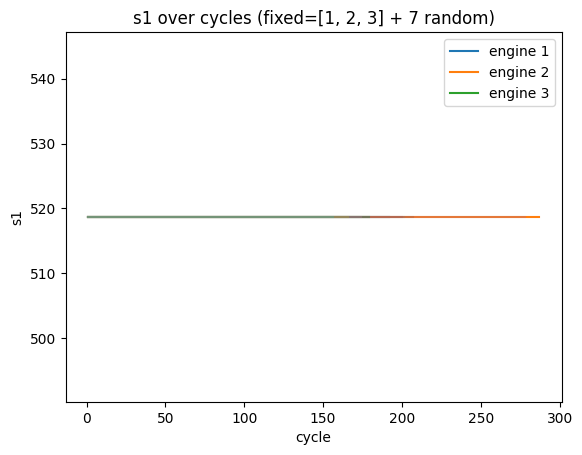

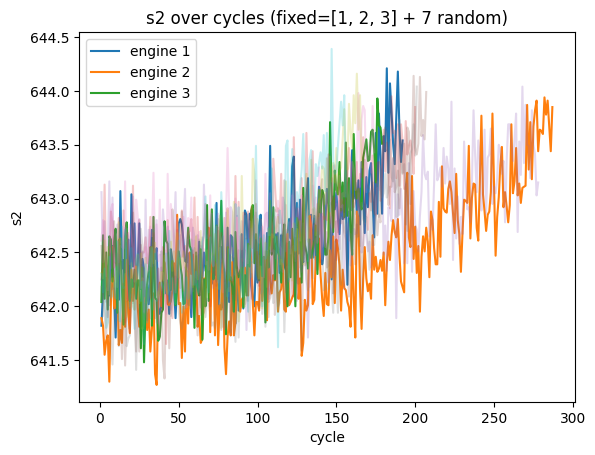

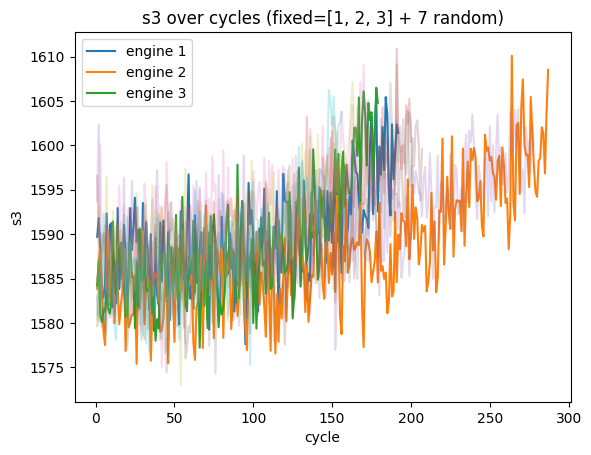

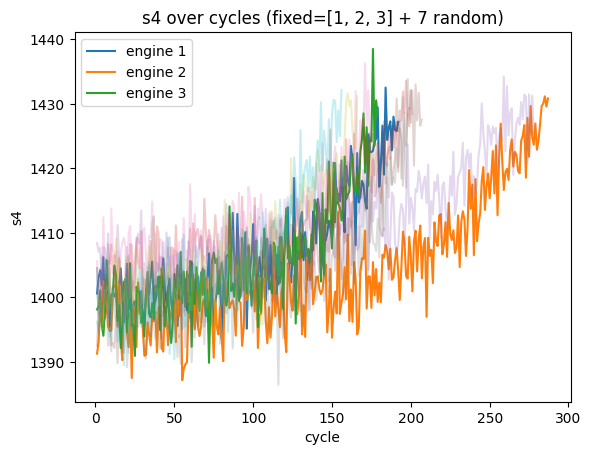

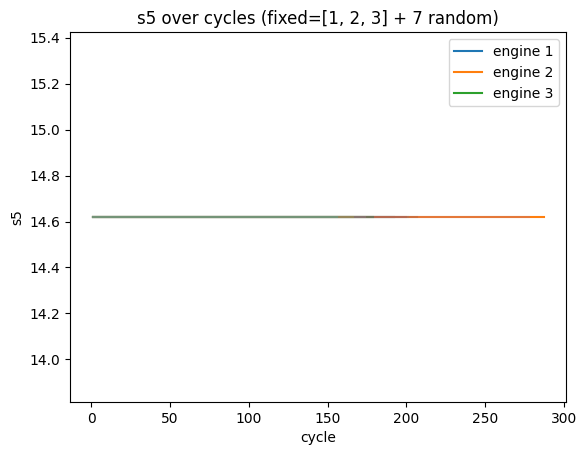

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fixed_engines = [1, 2, 3]
all_eng = df["engine_id"].unique()

def plot_sensor(sensor, random_n=7, seed=42):
    rng = np.random.default_rng(seed)
    rand_engines = rng.choice(all_eng, size=min(random_n, len(all_eng)), replace=False).tolist()
    engines = fixed_engines + [e for e in rand_engines if e not in fixed_engines]

    plt.figure()
    for eid in engines:
        sub = df[df["engine_id"] == eid]
        alpha = 1.0 if eid in fixed_engines else 0.25
        plt.plot(sub["cycle"], sub[sensor], alpha=alpha, label=f"engine {eid}" if eid in fixed_engines else None)

    plt.title(f"{sensor} over cycles (fixed={fixed_engines} + {random_n} random)")
    plt.xlabel("cycle")
    plt.ylabel(sensor)
    plt.legend()
    plt.show()

# Örnek: ilk 5 sensörü sırayla çiz
for s in ["s1", "s2", "s3", "s4", "s5"]:
    plot_sensor(s, random_n=7, seed=42)


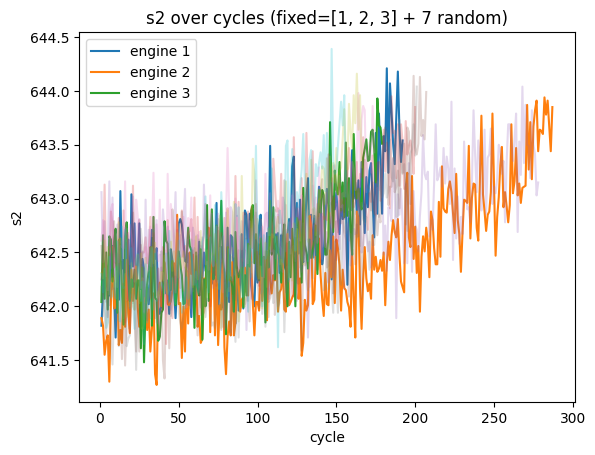

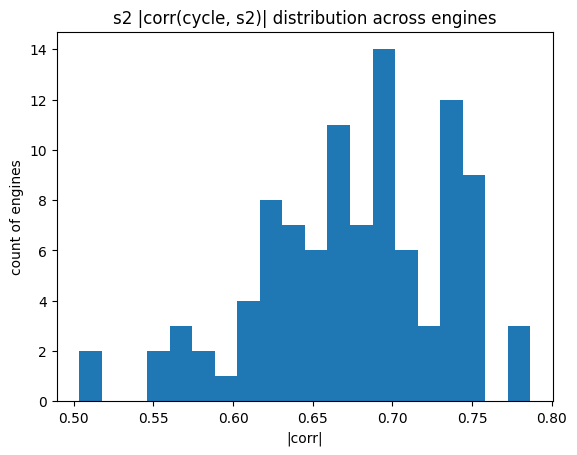

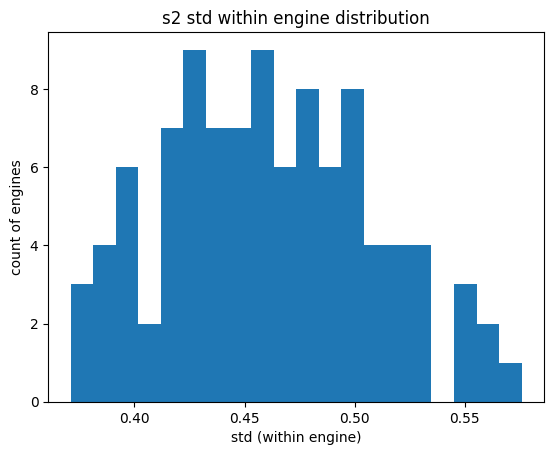

sensor: s2
engines: 100
pct |corr| > 0.3: 1.0
pct std_engine < 1e-3: 0.0
median |corr|: 0.6829715927577136
median std_engine: 0.45852178690862533


In [15]:
import matplotlib.pyplot as plt

def inspect_sensor(sensor: str, random_n=7, seed=42):
    per = summarize_sensor(df, sensor)

    # 1) Görsel çiz
    plot_sensor(sensor, random_n=random_n, seed=seed)

    # 2) Slope/Corr dağılımı
    plt.figure()
    plt.hist(per["corr"].dropna().abs(), bins=20)
    plt.title(f"{sensor} |corr(cycle, {sensor})| distribution across engines")
    plt.xlabel("|corr|")
    plt.ylabel("count of engines")
    plt.show()

    plt.figure()
    plt.hist(per["std_engine"].dropna(), bins=20)
    plt.title(f"{sensor} std within engine distribution")
    plt.xlabel("std (within engine)")
    plt.ylabel("count of engines")
    plt.show()

    # 3) Kısa özet sayı
    print("sensor:", sensor)
    print("engines:", per["engine_id"].nunique())
    print("pct |corr| > 0.3:", float((per["corr"].abs() > 0.3).mean()))
    print("pct std_engine < 1e-3:", float((per["std_engine"] < 1e-3).mean()))
    print("median |corr|:", float(np.nanmedian(per["corr"].abs())))
    print("median std_engine:", float(np.nanmedian(per["std_engine"])))

# Örnek
inspect_sensor("s2")


In [19]:
# 1) Her motorun train içindeki son cycle'ını bul
max_cycle = df.groupby("engine_id")["cycle"].max()

# 2) Her satır için RUL = (o motorun max cycle'ı) - (satırın cycle'ı)
df = df.copy()
df["RUL"] = df["engine_id"].map(max_cycle) - df["cycle"]

# 3) Hızlı kontrol: birkaç motorun ilk/son satırlarını görelim
check_ids = [1, 2, 3]
display(df[df["engine_id"].isin(check_ids)].groupby("engine_id").head(2))
display(df[df["engine_id"].isin(check_ids)].groupby("engine_id").tail(2))

print("RUL min/max:", df["RUL"].min(), df["RUL"].max())
print(df[["engine_id", "cycle", "RUL"]].head())


,engine_id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
192,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,2388.06,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585,286
193,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,2387.98,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085,285
479,3,1,0.0008,0.0005,100.0,518.67,642.04,1584.20,1398.13,14.62,...,2388.00,8138.40,8.4207,0.03,391,2388,100.0,38.96,23.3205,178
480,3,2,-0.0010,0.0000,100.0,518.67,642.66,1587.04,1398.62,14.62,...,2388.01,8137.38,8.3949,0.03,390,2388,100.0,39.07,23.4369,177


,engine_id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0
477,2,286,-0.0010,-0.0003,100.0,518.67,643.44,1603.63,1429.57,14.62,...,2388.22,8169.97,8.4932,0.03,395,2388,100.0,38.33,23.0169,1
478,2,287,-0.0005,0.0006,100.0,518.67,643.85,1608.50,1430.84,14.62,...,2388.21,8175.57,8.5365,0.03,398,2388,100.0,38.43,23.0848,0
656,3,178,-0.0010,0.0001,100.0,518.67,643.66,1606.50,1430.55,14.62,...,2388.12,8253.84,8.5351,0.03,399,2388,100.0,38.57,23.1323,1
657,3,179,0.0012,0.0000,100.0,518.67,643.51,1604.80,1428.23,14.62,...,2388.20,8255.34,8.5056,0.03,398,2388,100.0,38.40,22.9562,0


RUL min/max: 0 361
   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187


In [22]:
import numpy as np
import pandas as pd

# --- scipy spearman + warning fix ---
try:
    from scipy.stats import spearmanr
    try:
        from scipy.stats import ConstantInputWarning
        import warnings
        warnings.filterwarnings("ignore", category=ConstantInputWarning)
    except Exception:
        pass
except Exception as e:
    raise RuntimeError("scipy yok gibi görünüyor. 'pip install scipy' gerekebilir.") from e


# =========================================================
# 0) df hazır mı?
# =========================================================
assert isinstance(df, pd.DataFrame), "df bir pandas DataFrame olmalı."
assert "engine_id" in df.columns and "cycle" in df.columns, "df içinde engine_id ve cycle olmalı."

df = df.copy()
df = df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# Sensör kolonlarını otomatik bul (s1..s21)
sensor_cols = sorted(
    [c for c in df.columns if isinstance(c, str) and c.startswith("s") and c[1:].isdigit()],
    key=lambda x: int(x[1:])
)

# =========================================================
# 1) RUL üret (yoksa)
# =========================================================
if "RUL" not in df.columns:
    max_cycle = df.groupby("engine_id")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]

# =========================================================
# 2) Güvenli Spearman (sabit dizi -> NaN)
# =========================================================
def safe_spearman(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    if np.nanstd(x) < 1e-12 or np.nanstd(y) < 1e-12:
        return np.nan
    rho, _ = spearmanr(x, y)
    if not np.isfinite(rho):
        return np.nan
    return float(rho)

# =========================================================
# 3) Metrikler
#    - per-engine Spearman(sensor, RUL) -> signed + abs
#    - per-engine slope (sensor ~ cycle) / global_std
#    - per-engine effect: last20% median - first20% median, / global_std
#    - low var engine pct: std(sensor) < 1e-3
# =========================================================
engines = df["engine_id"].unique()
n_eng = len(engines)

global_std = df[sensor_cols].std(axis=0, ddof=0).replace(0, np.nan)

rows = []
for s in sensor_cols:
    rhos = []
    slope_norms = []
    effects = []
    low_var_cnt = 0

    gstd = global_std.get(s, np.nan)

    for eid, g in df.groupby("engine_id", sort=False):
        x_rul = g["RUL"].values
        y = g[s].values
        cyc = g["cycle"].values

        # low variance within engine
        if np.nanstd(y) < 1e-3:
            low_var_cnt += 1

        # spearman(sensor, RUL)
        rho = safe_spearman(y, x_rul)
        if np.isfinite(rho):
            rhos.append(rho)

        # slope(sensor ~ cycle) normalized by global std
        if np.isfinite(gstd) and gstd > 0 and len(g) >= 3:
            mask = np.isfinite(cyc) & np.isfinite(y)
            if mask.sum() >= 3 and np.nanstd(y[mask]) > 1e-12:
                try:
                    m = np.polyfit(cyc[mask], y[mask], 1)[0]
                    slope_norms.append(m / gstd)
                except Exception:
                    pass

            # effect: median(last 20%) - median(first 20%) / global std
            # (quantile ile böl)
            if mask.sum() >= 5:
                cc = cyc[mask]
                yy = y[mask]
                q1 = np.quantile(cc, 0.20)
                q2 = np.quantile(cc, 0.80)
                early = yy[cc <= q1]
                late  = yy[cc >= q2]
                if early.size >= 2 and late.size >= 2:
                    eff = (np.nanmedian(late) - np.nanmedian(early)) / gstd
                    if np.isfinite(eff):
                        effects.append(eff)

    rhos_arr = np.array(rhos, dtype=float)
    slope_arr = np.array(slope_norms, dtype=float)
    eff_arr = np.array(effects, dtype=float)

    engines_used = int(np.isfinite(rhos_arr).sum())
    med_rho = np.nanmedian(rhos_arr) if engines_used > 0 else np.nan
    med_abs_rho = np.nanmedian(np.abs(rhos_arr)) if engines_used > 0 else np.nan
    pct_rho_gt_030 = float(np.mean(np.abs(rhos_arr) > 0.30)) if engines_used > 0 else 0.0

    pct_pos = float(np.mean(rhos_arr > 0)) if engines_used > 0 else 0.0
    pct_neg = float(np.mean(rhos_arr < 0)) if engines_used > 0 else 0.0
    if pct_pos >= 0.60:
        direction = "mostly_positive"
    elif pct_neg >= 0.60:
        direction = "mostly_negative"
    else:
        direction = "mixed"

    med_abs_slope_norm = float(np.nanmedian(np.abs(slope_arr))) if slope_arr.size > 0 else np.nan
    med_abs_eff = float(np.nanmedian(np.abs(eff_arr))) if eff_arr.size > 0 else np.nan
    pct_eff_gt_050 = float(np.mean(np.abs(eff_arr) > 0.50)) if eff_arr.size > 0 else 0.0

    pct_low_var_eng = low_var_cnt / n_eng if n_eng > 0 else np.nan
    gstd_val = float(global_std.get(s, np.nan)) if np.isfinite(global_std.get(s, np.nan)) else 0.0

    # --- Score: senin önceki çıktılarına uyan formül ---
    # score ≈ median_abs_spearman_RUL + 0.16 * median_abs_effect
    # + low_var engine oranına göre çarpanla baskıla
    base_score = (0.0 if not np.isfinite(med_abs_rho) else med_abs_rho) + 0.16 * (0.0 if not np.isfinite(med_abs_eff) else med_abs_eff)
    score = base_score * (1.0 - pct_low_var_eng)

    rows.append({
        "sensor": s,
        "engines_used": engines_used,
        "median_spearman_RUL": med_rho,                 # NEW (signed)
        "median_abs_spearman_RUL": med_abs_rho,
        "pct(|spearman|>0.30)": pct_rho_gt_030,
        "pct_pos": pct_pos,                             # NEW
        "pct_neg": pct_neg,                             # NEW
        "direction": direction,                         # NEW (mostly_positive/mostly_negative/mixed)
        "median_abs_slope_norm": med_abs_slope_norm,
        "median_abs_effect": med_abs_eff,
        "pct(|effect|>0.50)": pct_eff_gt_050,
        "pct_low_var_eng": float(pct_low_var_eng),
        "global_std": gstd_val,
        "score": float(score),
    })

rul_metrics_df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)

# =========================================================
# 4) Özet çıktılar
# =========================================================
print(f"df shape={df.shape} | engines={n_eng} | sensors={len(sensor_cols)}")
print(f"RUL örnek: min={df['RUL'].min()} max={df['RUL'].max()}")

# Muhtemelen sabit / çok düşük varyanslı sensörler
low_var_sensors = rul_metrics_df[rul_metrics_df["pct_low_var_eng"] >= 0.95].copy()
print("\nMuhtemelen sabit / çok düşük varyanslı sensörler (motorların %95+'inde std < 1e-3):")
display(low_var_sensors[["sensor", "pct_low_var_eng", "global_std", "score"]].head(20))

# Top 12 sensör
print("\nTop 12 sensör (RUL'a göre):")
display(rul_metrics_df.head(12))

print("\nTüm metrik tablosu: rul_metrics_df (DataFrame)")


df shape=(20631, 27) | engines=100 | sensors=21
RUL örnek: min=0 max=361

Muhtemelen sabit / çok düşük varyanslı sensörler (motorların %95+'inde std < 1e-3):


,sensor,pct_low_var_eng,global_std,score
15,s10,1.0,0.000000e+00,0.0
16,s5,1.0,5.329071e-15,0.0
17,s16,1.0,3.469447e-18,0.0
18,s18,1.0,0.000000e+00,0.0
19,s19,1.0,0.000000e+00,0.0
20,s1,1.0,0.000000e+00,0.0



Top 12 sensör (RUL'a göre):


,sensor,engines_used,median_spearman_RUL,median_abs_spearman_RUL,pct(|spearman|>0.30),pct_pos,pct_neg,direction,median_abs_slope_norm,median_abs_effect,pct(|effect|>0.50),pct_low_var_eng,global_std,score
0,s11,100,-0.819030,0.819030,1.00,0.0,1.0,mostly_negative,0.012485,2.003138,1.00,0.0,0.267081,1.139532
1,s12,100,0.807523,0.807523,1.00,1.0,0.0,mostly_positive,0.011462,2.016852,1.00,0.0,0.737536,1.130219
2,s4,100,-0.783958,0.783958,1.00,0.0,1.0,mostly_negative,0.012143,2.037135,1.00,0.0,9.000387,1.109900
3,s7,100,0.774188,0.774188,1.00,1.0,0.0,mostly_positive,0.011197,1.895329,1.00,0.0,0.885071,1.077441
4,s8,100,-0.768409,0.768409,0.92,0.0,1.0,mostly_negative,0.009827,1.690528,0.93,0.0,0.070984,1.038894
5,s13,100,-0.761977,0.761977,0.93,0.0,1.0,mostly_negative,0.009734,1.703348,0.89,0.0,0.071917,1.034513
6,s15,100,-0.720953,0.720953,1.00,0.0,1.0,mostly_negative,0.011378,1.898458,1.00,0.0,0.037504,1.024706
7,s21,100,0.708005,0.708005,1.00,1.0,0.0,mostly_positive,0.011283,1.895412,1.00,0.0,0.108248,1.011271
8,s20,100,0.705943,0.705943,1.00,1.0,0.0,mostly_positive,0.011151,1.825806,1.00,0.0,0.180742,0.998072
9,s17,100,-0.660865,0.660865,1.00,0.0,1.0,mostly_negative,0.010961,1.937077,1.00,0.0,1.548725,0.970797



Tüm metrik tablosu: rul_metrics_df (DataFrame)


In [23]:
import re
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# =========================
# MODE B — RUL ANALYSIS ONLY
# (no plots, no file writes)
# =========================

# ---- 0) Input DF: df varsayımı ----
if "df" not in globals() or not isinstance(df, pd.DataFrame):
    raise ValueError("Bu hücreyi çalıştırmadan önce `df` DataFrame'inin hazır olması lazım.")

required_cols = {"engine_id", "cycle"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"DataFrame'de eksik kolon(lar): {missing}")

# Sensör kolonlarını yakala: s1..s21
sensor_cols = [c for c in df.columns if re.fullmatch(r"s\d+", str(c))]
sensor_cols = sorted(sensor_cols, key=lambda x: int(x[1:]))

if len(sensor_cols) == 0:
    raise ValueError("Sensör kolonu bulunamadı (s1, s2, ... formatında olmalı).")

# ---- 1) RUL hesapla (yoksa) ----
df_work = df.copy()
if "RUL" not in df_work.columns:
    max_cycle = df_work.groupby("engine_id")["cycle"].transform("max")
    df_work["RUL"] = (max_cycle - df_work["cycle"]).astype(int)

n_engines = df_work["engine_id"].nunique()
print(f"df shape={df_work.shape} | engines={n_engines} | sensors={len(sensor_cols)}")
print(f"RUL range: {df_work['RUL'].min()}..{df_work['RUL'].max()}")

# ---- 2) Helper'lar (uyarı spam yok) ----
def _safe_spearman(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) < 3:
        return np.nan
    if np.nanstd(x) < 1e-12 or np.nanstd(y) < 1e-12:
        return np.nan
    return spearmanr(x, y, nan_policy="omit").correlation

def _engine_effect_size(series, frac=0.1, min_n=6):
    s = np.asarray(series, dtype=float)
    n = len(s)
    if n < min_n:
        return np.nan
    k = max(int(np.floor(n * frac)), 2)
    early = s[:k]
    late = s[-k:]
    std_all = np.nanstd(s)
    if std_all < 1e-12:
        return np.nan
    return (np.nanmean(late) - np.nanmean(early)) / std_all

def _engine_slope_norm(cycle, series):
    x = np.asarray(cycle, dtype=float)
    y = np.asarray(series, dtype=float)
    if len(x) < 3:
        return np.nan
    y_std = np.nanstd(y)
    if y_std < 1e-12:
        return np.nan
    x0 = x - np.nanmean(x)
    denom = np.nansum(x0 * x0)
    if denom < 1e-12:
        return np.nan
    slope = np.nansum(x0 * (y - np.nanmean(y))) / denom
    cr = (np.nanmax(x) - np.nanmin(x))
    if cr < 1e-12:
        return np.nan
    return (slope * cr) / y_std

# ---- 3) Parametreler ----
LOW_VAR_STD_TH = 1e-3
LOW_VAR_PCT_TH = 0.95
SPEARMAN_TH = 0.30
EFFECT_TH = 0.50

# ---- 4) Sensör metrikleri ----
df_sorted = df_work.sort_values(["engine_id", "cycle"])
rows = []

for s in sensor_cols:
    std_per_eng = df_sorted.groupby("engine_id")[s].std(ddof=0)
    pct_low_var_eng = float((std_per_eng < LOW_VAR_STD_TH).mean())
    global_std = float(df_sorted[s].std(ddof=0))

    spearmans = []
    slopes = []
    effects = []

    for _, g in df_sorted.groupby("engine_id", sort=False):
        y = g[s].to_numpy()
        rul = g["RUL"].to_numpy()
        cyc = g["cycle"].to_numpy()

        r = _safe_spearman(y, rul)
        if not np.isnan(r):
            spearmans.append(r)

        sl = _engine_slope_norm(cyc, y)
        if not np.isnan(sl):
            slopes.append(abs(sl))

        ef = _engine_effect_size(y, frac=0.1)
        if not np.isnan(ef):
            effects.append(ef)

    spearmans = np.array(spearmans, dtype=float)
    slopes = np.array(slopes, dtype=float)
    effects = np.array(effects, dtype=float)

    engines_used = int(np.sum(~np.isnan(spearmans)))

    if engines_used > 0:
        median_spearman = float(np.nanmedian(spearmans))
        median_abs_spearman = float(np.nanmedian(np.abs(spearmans)))
        pct_spear_strong = float(np.mean(np.abs(spearmans) > SPEARMAN_TH))
        pct_pos = float(np.mean(spearmans > 0))
        pct_neg = float(np.mean(spearmans < 0))
    else:
        median_spearman = np.nan
        median_abs_spearman = 0.0
        pct_spear_strong = 0.0
        pct_pos = 0.0
        pct_neg = 0.0

    if pct_pos >= 0.7:
        direction = "mostly_positive"
    elif pct_neg >= 0.7:
        direction = "mostly_negative"
    else:
        direction = "mixed"

    median_abs_slope_norm = float(np.nanmedian(slopes)) if len(slopes) else 0.0

    if len(effects):
        median_abs_effect = float(np.nanmedian(np.abs(effects)))
        pct_effect_strong = float(np.mean(np.abs(effects) > EFFECT_TH))
    else:
        median_abs_effect = 0.0
        pct_effect_strong = 0.0

    # Skor (aynı mantık): güçlü ilişki + yaygınlık + trend etkisi - low-var ceza
    score = (
        0.60 * median_abs_spearman +
        0.20 * pct_spear_strong +
        0.20 * np.clip(median_abs_effect / 2.0, 0, 1)
    ) - (0.60 * pct_low_var_eng)

    rows.append({
        "sensor": s,
        "engines_used": engines_used,
        "median_spearman_RUL": median_spearman,
        "median_abs_spearman_RUL": median_abs_spearman,
        "pct(|spearman|>0.30)": pct_spear_strong,
        "pct_pos": pct_pos,
        "pct_neg": pct_neg,
        "direction": direction,
        "median_abs_slope_norm": median_abs_slope_norm,
        "median_abs_effect": median_abs_effect,
        "pct(|effect|>0.50)": pct_effect_strong,
        "pct_low_var_eng": pct_low_var_eng,
        "global_std": global_std,
        "score": float(score),
    })

rul_metrics_df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)

# ---- 5) Low-var tespiti (çıktı) ----
likely_constant = rul_metrics_df[rul_metrics_df["pct_low_var_eng"] >= LOW_VAR_PCT_TH] \
    .sort_values(["pct_low_var_eng", "global_std"], ascending=[False, True]) \
    [["sensor", "pct_low_var_eng", "global_std", "score"]]

print("\nMuhtemelen sabit / çok düşük varyanslı sensörler (>= %95 motor std < 1e-3):")
print(likely_constant.to_string(index=False) if len(likely_constant) else "  (Yok)")

# ---- 6) Seçim / Eleme ----
TOP_K = 12

drop_lowvar = set(rul_metrics_df.loc[rul_metrics_df["pct_low_var_eng"] >= LOW_VAR_PCT_TH, "sensor"])
drop_low_coverage = set(rul_metrics_df.loc[rul_metrics_df["engines_used"] < int(0.7 * n_engines), "sensor"])

candidates = [s for s in rul_metrics_df["sensor"].tolist()
              if s not in drop_lowvar and s not in drop_low_coverage]

selected_sensors = candidates[:TOP_K]
dropped_sensors = sorted(list(set(sensor_cols) - set(selected_sensors)))

print(f"\nTop {TOP_K} (score'a göre) sensörler:")
print(rul_metrics_df.head(TOP_K).to_string(index=False))

print("\n--- SEÇİM ÖZETİ ---")
print("Selected sensors:", selected_sensors)
print("Dropped sensors :", dropped_sensors)

# ---- 7) Çıktı DF'leri hazırla ----
setting_cols = [c for c in df_work.columns if str(c).startswith("setting_")]
base_cols = ["engine_id", "cycle"] + setting_cols + ["RUL"]

df_selected = df_work[base_cols + selected_sensors].copy()

# Direction hizalama opsiyonel (şimdilik açık bırakıyorum, istersen kapatırız)
ALIGN_DIRECTION = True
df_aligned = df_selected.copy()
flip_sensors = []

if ALIGN_DIRECTION:
    dir_map = rul_metrics_df.set_index("sensor")["direction"].to_dict()
    for s in selected_sensors:
        if dir_map.get(s) == "mostly_negative":
            df_aligned[s] = -1.0 * df_aligned[s]
            flip_sensors.append(s)

print("\nDirection alignment:", "ON" if ALIGN_DIRECTION else "OFF")
print("Flipped sensors (mostly_negative):", flip_sensors)

# Notebook'ta kullanacağın ana değişkenler:
# - rul_metrics_df (tüm tablo)
# - likely_constant (low-var tablo)
# - selected_sensors / dropped_sensors
# - df_selected / df_aligned


df shape=(20631, 27) | engines=100 | sensors=21
RUL range: 0..361

Muhtemelen sabit / çok düşük varyanslı sensörler (>= %95 motor std < 1e-3):
sensor  pct_low_var_eng   global_std  score
   s10              1.0 0.000000e+00   -0.6
   s18              1.0 0.000000e+00   -0.6
   s19              1.0 0.000000e+00   -0.6
    s1              1.0 0.000000e+00   -0.6
   s16              1.0 3.469447e-18   -0.6
    s5              1.0 5.329071e-15   -0.6

Top 12 (score'a göre) sensörler:
sensor  engines_used  median_spearman_RUL  median_abs_spearman_RUL  pct(|spearman|>0.30)  pct_pos  pct_neg       direction  median_abs_slope_norm  median_abs_effect  pct(|effect|>0.50)  pct_low_var_eng  global_std    score
   s11           100            -0.819030                 0.819030                  1.00     0.00     1.00 mostly_negative               2.812251           2.875493                1.00              0.0    0.267081 0.891418
   s12           100             0.807523                 0.807523   

Plotting sensors: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']


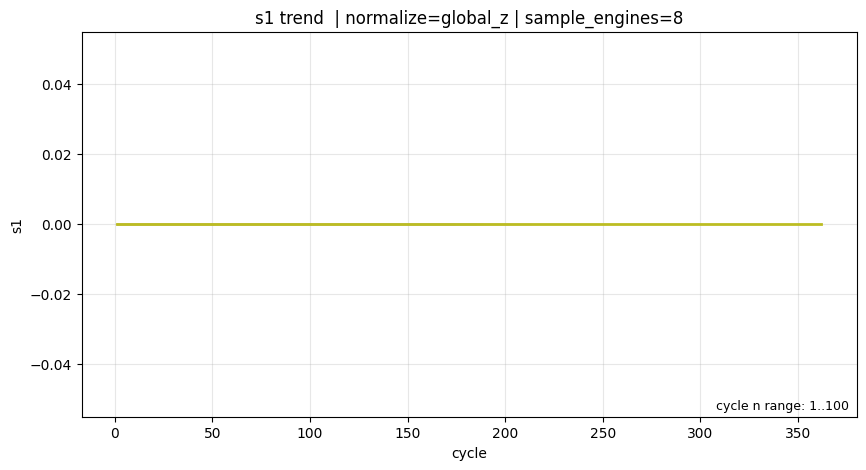

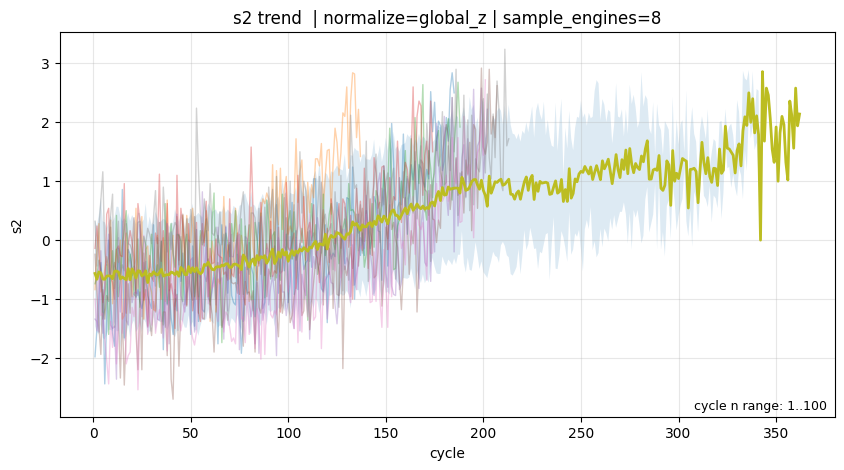

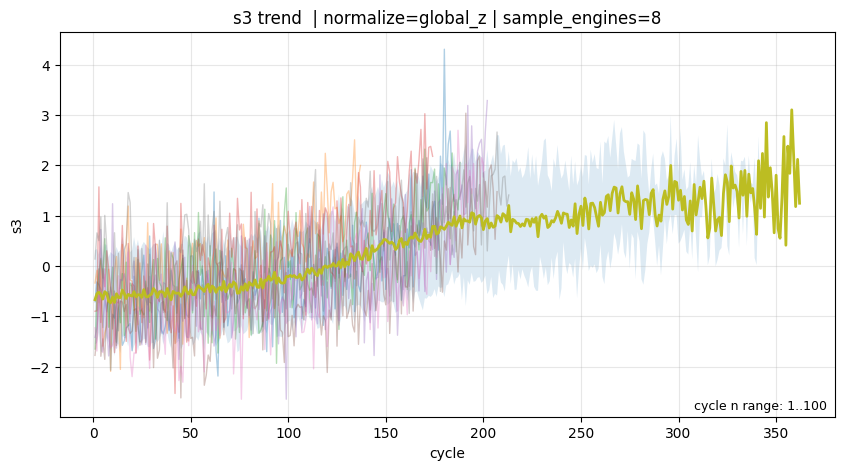

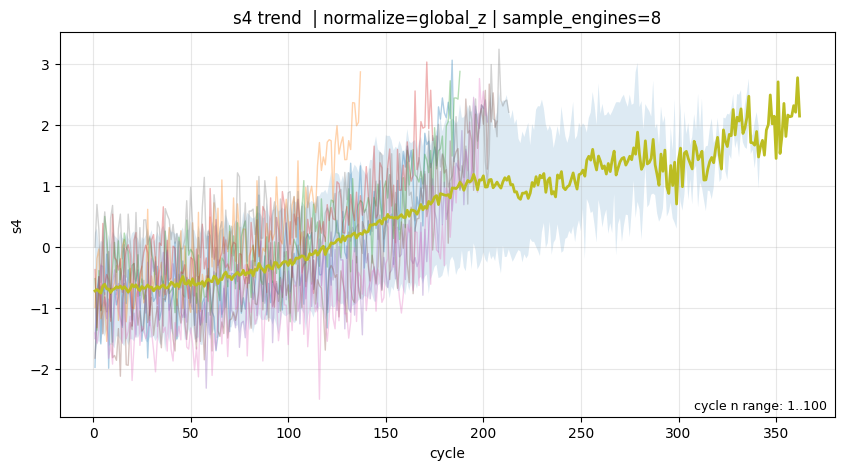

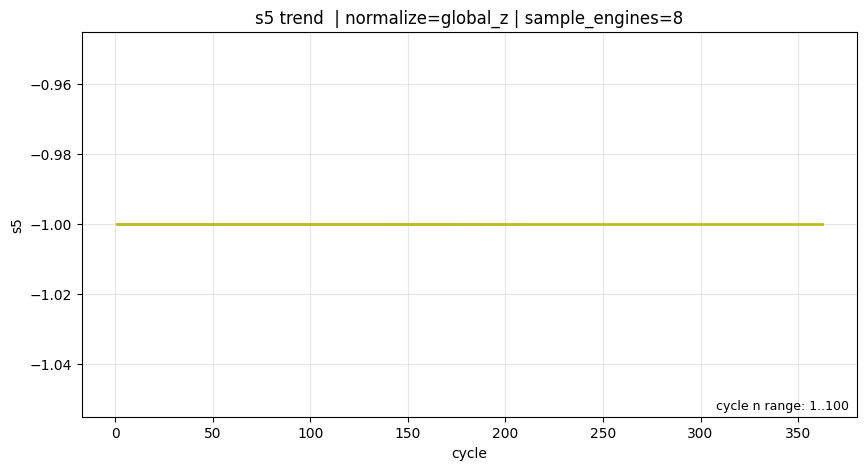

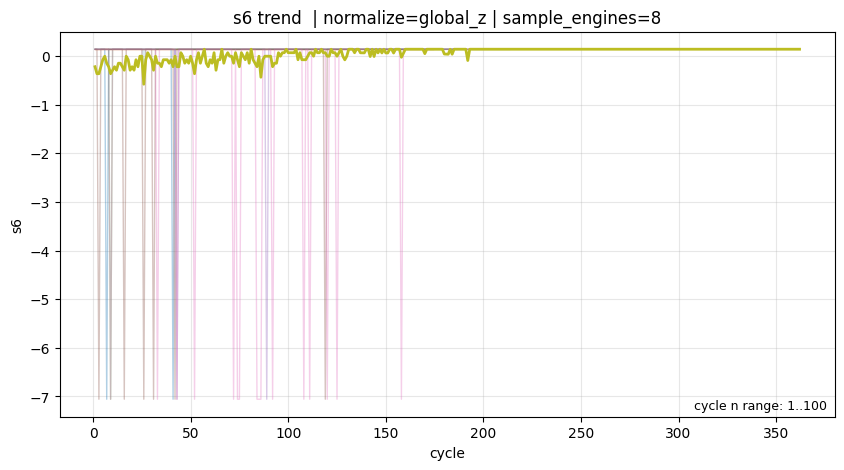

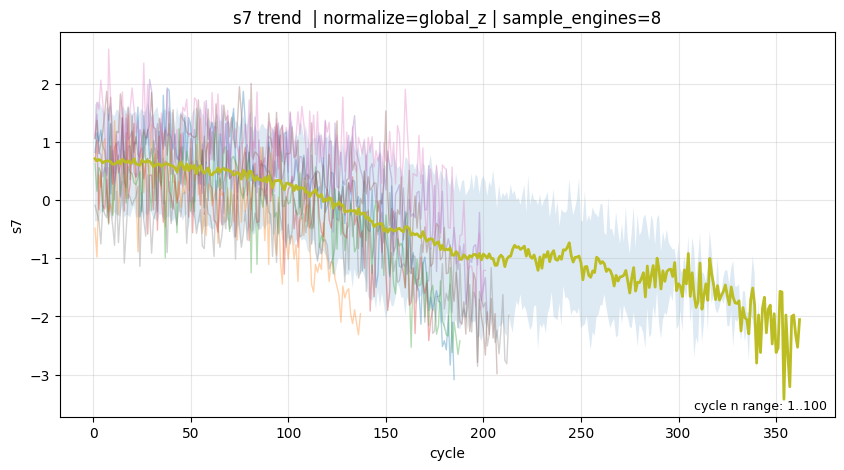

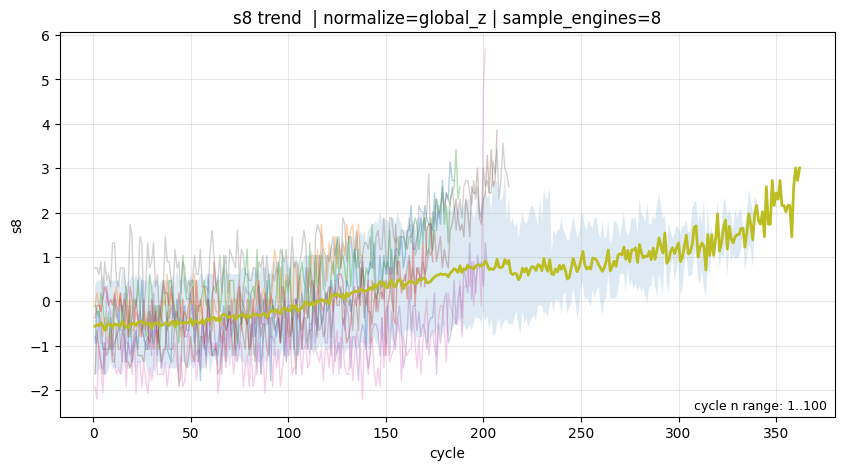

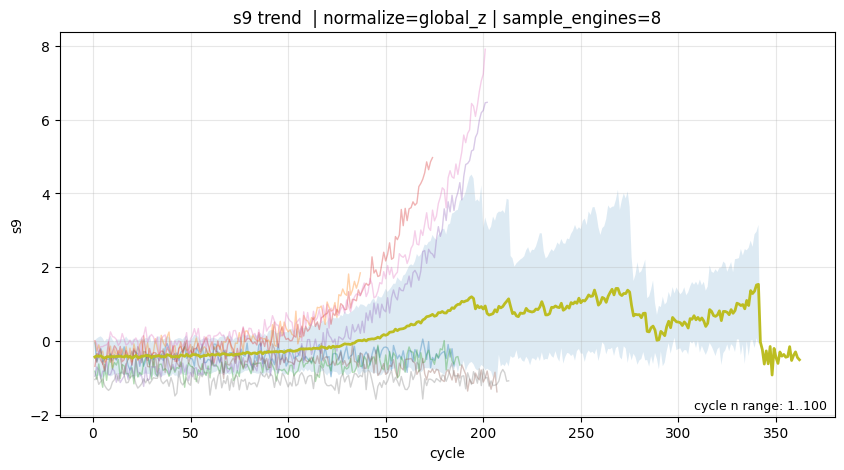

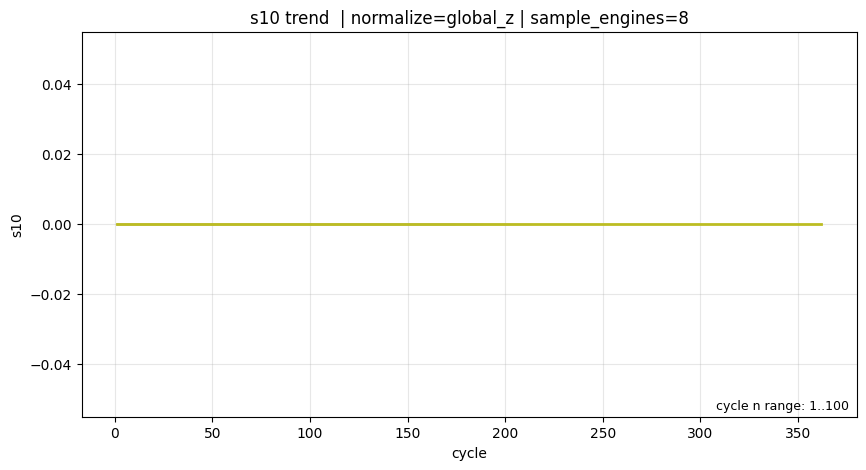

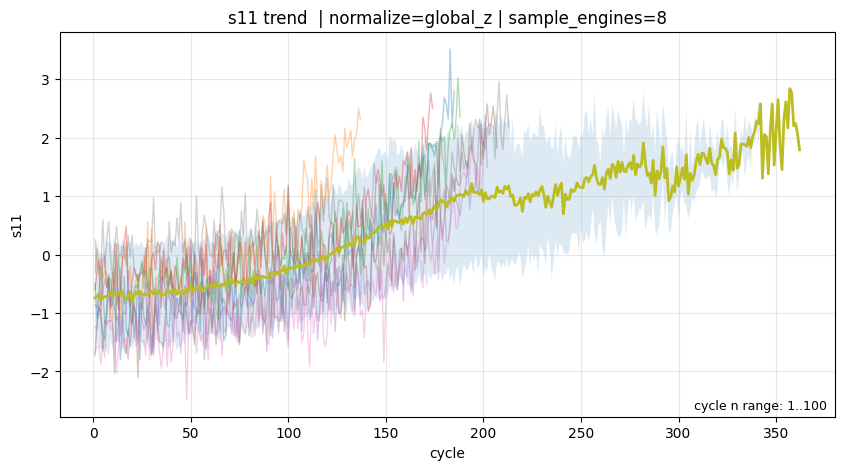

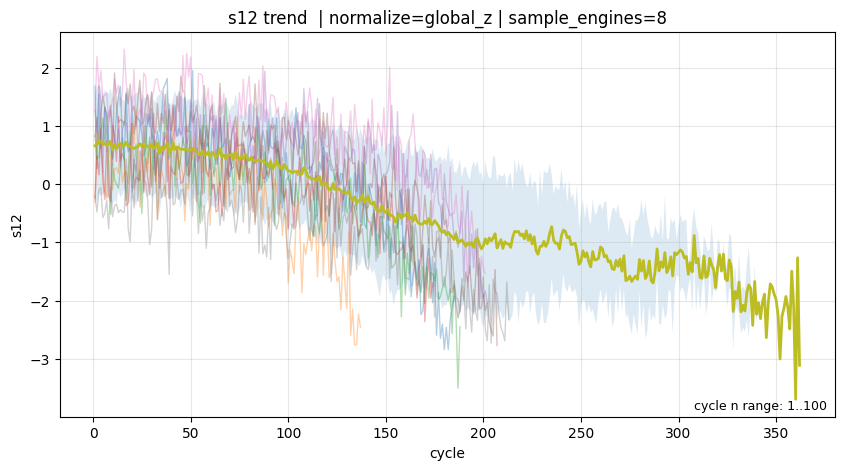

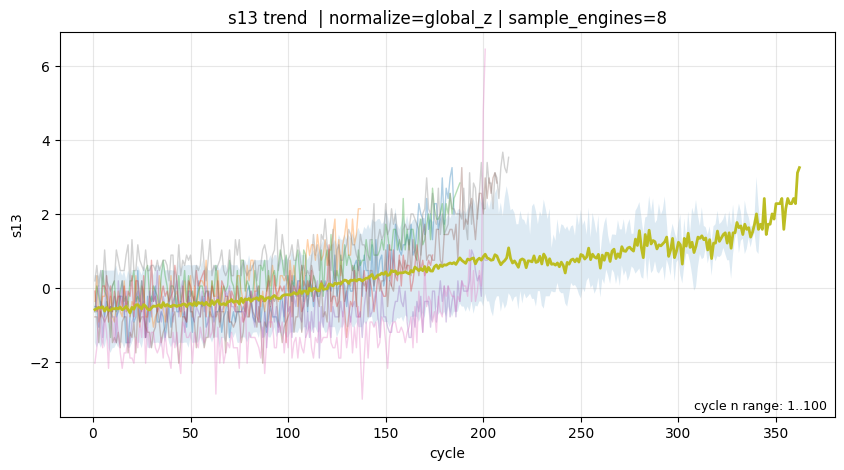

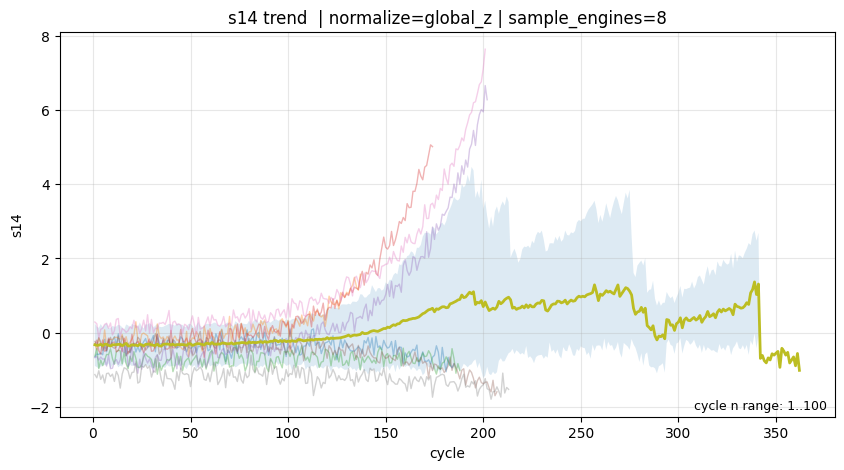

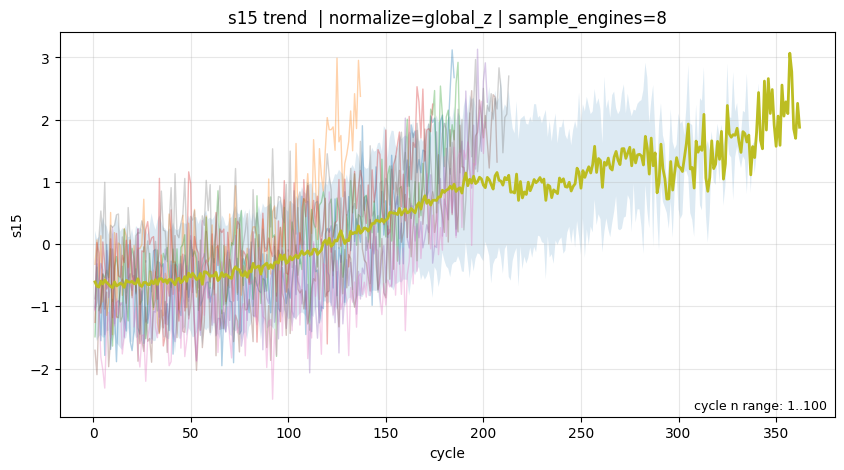

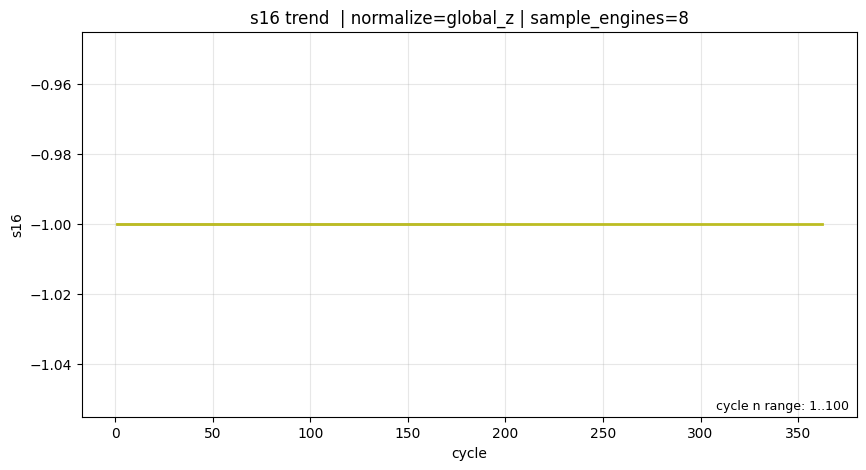

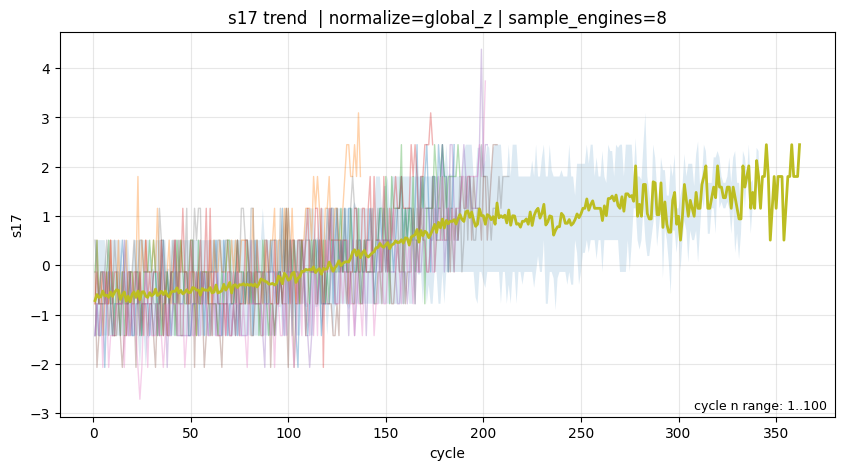

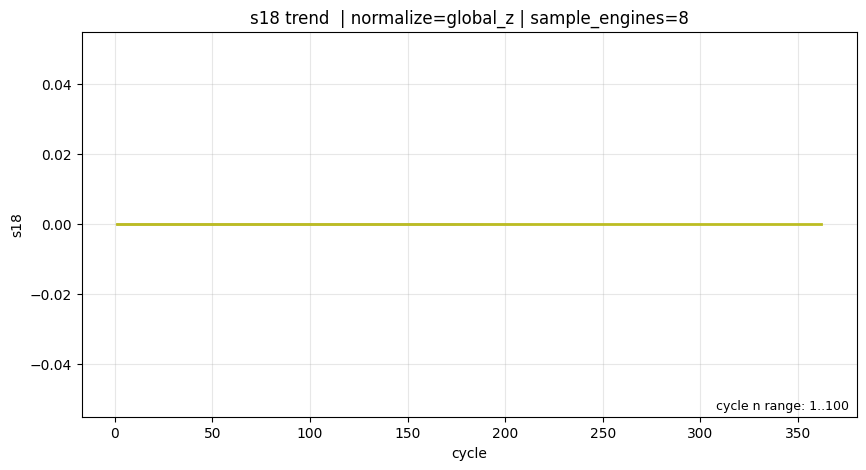

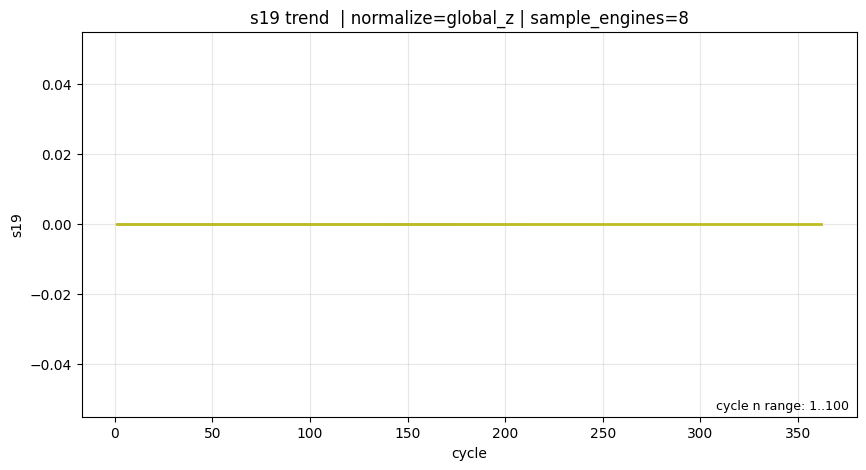

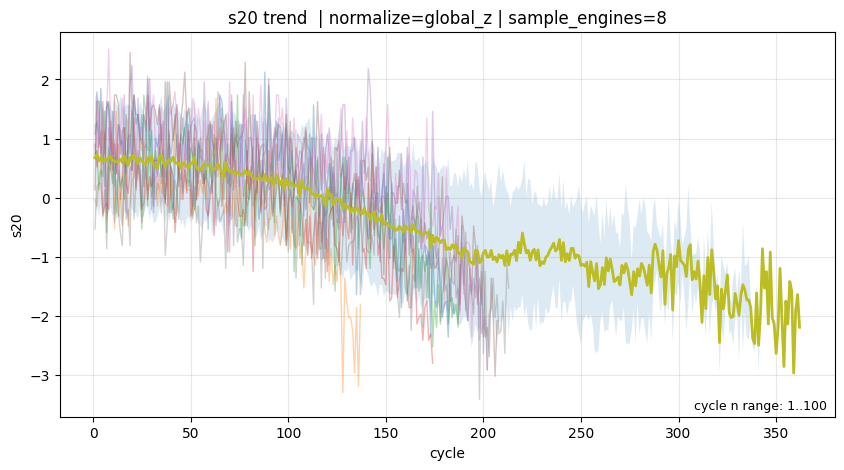

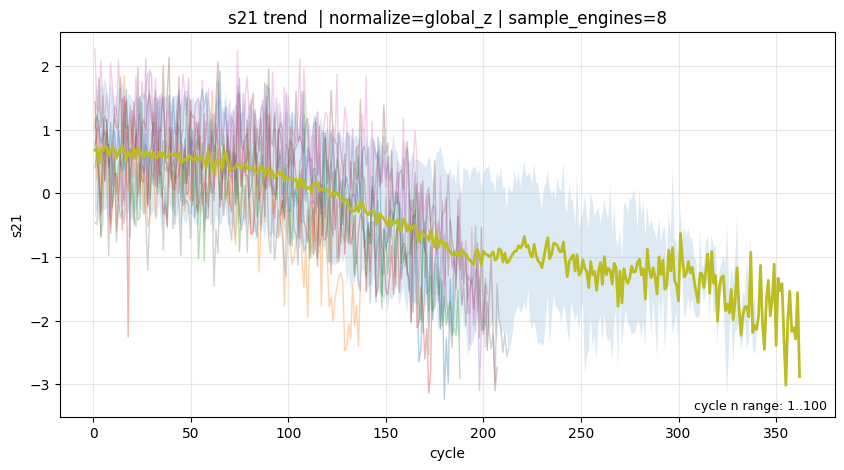


Dropped sensors: ['s1', 's10', 's16', 's17', 's18', 's19', 's3', 's5', 's6']
Kept sensors: ['s2', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's20', 's21']
Saved figures to: figures/sensor_trends


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
ENGINE_COL = "engine_id"
CYCLE_COL  = "cycle"

SENSORS_ALL  = [f"s{i}" for i in range(1, 22)]
SENSORS_DROP = ['s1','s10','s16','s17','s18','s19','s3','s5','s6']
SENSORS_KEEP = [s for s in SENSORS_ALL if s not in SENSORS_DROP]

PLOT_ALL_SENSORS = True   # False yaparsan sadece KEEP çizilir
N_SAMPLE_ENGINES = 8      # her sensör grafiğinde gösterilecek örnek motor sayısı
RANDOM_SEED = 42

SAVE_FIGS = True
FIG_DIR = "figures/sensor_trends"
os.makedirs(FIG_DIR, exist_ok=True)

# normalize seçenekleri: "none", "global_z", "per_engine_z"
NORMALIZE = "global_z"

# =========================
# HELPERS
# =========================
def _apply_normalization(df_in: pd.DataFrame, sensor: str, how: str) -> pd.DataFrame:
    df = df_in.copy()

    if how == "none":
        return df

    if how == "global_z":
        mu = df[sensor].mean()
        sd = df[sensor].std(ddof=0)
        if sd == 0 or np.isnan(sd):
            df[sensor] = 0.0
        else:
            df[sensor] = (df[sensor] - mu) / sd
        return df

    if how == "per_engine_z":
        # her engine kendi içinde standardize edilir (trend şekli daha net görünür)
        def z(x):
            sd = x.std(ddof=0)
            if sd == 0 or np.isnan(sd):
                return x * 0.0
            return (x - x.mean()) / sd
        df[sensor] = df.groupby(ENGINE_COL)[sensor].transform(z)
        return df

    raise ValueError("NORMALIZE must be one of: 'none', 'global_z', 'per_engine_z'")

def plot_sensor_trend(df: pd.DataFrame, sensor: str,
                      n_sample_engines: int = 8,
                      normalize: str = "global_z",
                      seed: int = 42,
                      save: bool = True,
                      fig_dir: str = FIG_DIR):
    # gerekli kolonlar
    needed = {ENGINE_COL, CYCLE_COL, sensor}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns for {sensor}: {missing}")

    d = df[[ENGINE_COL, CYCLE_COL, sensor]].dropna().copy()
    d = _apply_normalization(d, sensor, normalize)

    # örnek motor seç
    rng = np.random.default_rng(seed)
    engines = d[ENGINE_COL].unique()
    if len(engines) == 0:
        print(f"[SKIP] {sensor}: no data")
        return
    pick = engines if len(engines) <= n_sample_engines else rng.choice(engines, size=n_sample_engines, replace=False)

    # cycle bazında özet (mean + quantile band + count)
    g = d.groupby(CYCLE_COL)[sensor]
    summary = pd.DataFrame({
        "mean": g.mean(),
        "q10":  g.quantile(0.10),
        "q90":  g.quantile(0.90),
        "n":    g.size()
    }).reset_index()

    # çiz
    plt.figure(figsize=(10, 5))

    # örnek motor eğrileri
    for eid in pick:
        sub = d[d[ENGINE_COL] == eid].sort_values(CYCLE_COL)
        plt.plot(sub[CYCLE_COL], sub[sensor], alpha=0.35, linewidth=1)

    # mean + band
    plt.plot(summary[CYCLE_COL], summary["mean"], linewidth=2)
    plt.fill_between(summary[CYCLE_COL], summary["q10"], summary["q90"], alpha=0.15)

    plt.title(f"{sensor} trend  | normalize={normalize} | sample_engines={len(pick)}")
    plt.xlabel("cycle")
    plt.ylabel(sensor)
    plt.grid(True, alpha=0.3)

    # sağ alt: her cycle'da kaç engine var (çok düşerse son kısımlar güvenilmez)
    # not: ikinci y-ekseni açmadan hafif bir not olarak yazalım
    min_n = int(summary["n"].min())
    max_n = int(summary["n"].max())
    plt.text(0.99, 0.01, f"cycle n range: {min_n}..{max_n}", transform=plt.gca().transAxes,
             ha="right", va="bottom", fontsize=9)

    if save:
        out = os.path.join(fig_dir, f"{sensor}_trend_{normalize}.png")
        plt.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()

# =========================
# RUN
# =========================
SENSORS_TO_PLOT = SENSORS_ALL if PLOT_ALL_SENSORS else SENSORS_KEEP

print("Plotting sensors:", SENSORS_TO_PLOT)
for s in SENSORS_TO_PLOT:
    plot_sensor_trend(df, s,
                      n_sample_engines=N_SAMPLE_ENGINES,
                      normalize=NORMALIZE,
                      seed=RANDOM_SEED,
                      save=SAVE_FIGS,
                      fig_dir=FIG_DIR)

print("\nDropped sensors:", SENSORS_DROP)
print("Kept sensors:", SENSORS_KEEP)
if SAVE_FIGS:
    print("Saved figures to:", FIG_DIR)


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

RAW_DIR = Path("../data/raw/CMAPSSData")
train_path = RAW_DIR / "train_FD001.txt"

if not train_path.exists():
    raise FileNotFoundError(f"Bulamadım: {train_path.resolve()}")

print("✅ train_FD001.txt bulundu:", train_path.resolve())

# FD001 formatı: id, cycle, setting1-3, s1-s21 (toplam 26 sütun)
cols = ["engine_id","cycle","setting1","setting2","setting3"] + [f"s{i}" for i in range(1,22)]
df = pd.read_csv(train_path, sep=r"\s+", header=None, names=cols)

# RUL: train set için her motorun max cycle'ından hesaplanır
max_cycle = df.groupby("engine_id")["cycle"].max()
df["RUL"] = df["engine_id"].map(max_cycle) - df["cycle"]

CHECK_SENSORS = ["s3","s17"]

def spearman_corr(a, b):
    # pandas spearman hızlı ve stabil
    return pd.Series(a).corr(pd.Series(b), method="spearman")

def monotonicity_score(x, t):
    # t: cycle artan
    # basit: Spearman(x, cycle) mutlak değeri = monotonicity proxy
    return abs(spearman_corr(x, t))

rows = []
for s in CHECK_SENSORS:
    per_engine = []
    per_engine_rul = []
    per_engine_mono = []
    signs = []
    for eid, g in df.groupby("engine_id"):
        x = g[s].values
        rul = g["RUL"].values
        cyc = g["cycle"].values
        
        c = spearman_corr(x, rul)
        m = monotonicity_score(x, cyc)
        per_engine_rul.append(c)
        per_engine_mono.append(m)
        if not np.isnan(c) and c != 0:
            signs.append(np.sign(c))

    per_engine_rul = np.array(per_engine_rul, dtype=float)
    per_engine_mono = np.array(per_engine_mono, dtype=float)
    signs = np.array(signs, dtype=float)

    # işaret tutarlılığı: çoğunluk hangi yönde?
    if len(signs) > 0:
        pos_ratio = (signs > 0).mean()
        neg_ratio = (signs < 0).mean()
    else:
        pos_ratio = neg_ratio = np.nan

    rows.append({
        "sensor": s,
        "median_spearman(sensor,RUL)": np.nanmedian(per_engine_rul),
        "median_abs_spearman": np.nanmedian(np.abs(per_engine_rul)),
        "pct_engines_|spearman|>0.3": np.nanmean(np.abs(per_engine_rul) > 0.3),
        "median_monotonicity(|spearman(sensor,cycle)|)": np.nanmedian(per_engine_mono),
        "pct_pos_sign": pos_ratio,
        "pct_neg_sign": neg_ratio,
        "global_std": df[s].std()
    })

res = pd.DataFrame(rows).sort_values("median_abs_spearman", ascending=False)
display(res)

# Basit öneri
def recommend(row):
    # ayarlanabilir eşikler
    if row["global_std"] < 1e-6:
        return "DROP (sabit/çok düşük varyans)"
    if row["median_abs_spearman"] >= 0.5 and row["pct_engines_|spearman|>0.3"] >= 0.8 and max(row["pct_pos_sign"], row["pct_neg_sign"]) >= 0.8:
        return "KEEP (RUL ile güçlü ve tutarlı ilişki)"
    if row["median_abs_spearman"] >= 0.35 and row["pct_engines_|spearman|>0.3"] >= 0.6 and max(row["pct_pos_sign"], row["pct_neg_sign"]) >= 0.7:
        return "BORDERLINE (plot + SNR kontrol et)"
    return "DROP (zayıf/tutarsız ilişki)"

res["recommendation"] = res.apply(recommend, axis=1)
display(res[["sensor","median_spearman(sensor,RUL)","median_abs_spearman","pct_engines_|spearman|>0.3","pct_pos_sign","pct_neg_sign","global_std","recommendation"]])


✅ train_FD001.txt bulundu: /Users/elifsena/jet-cube-turbofan-mvp/data/raw/CMAPSSData/train_FD001.txt


,sensor,"median_spearman(sensor,RUL)",median_abs_spearman,pct_engines_|spearman|>0.3,"median_monotonicity(|spearman(sensor,cycle)|)",pct_pos_sign,pct_neg_sign,global_std
1,s17,-0.660865,0.660865,1.0,0.660865,0.0,1.0,1.548763
0,s3,-0.636769,0.636769,1.0,0.636769,0.0,1.0,6.131150


,sensor,"median_spearman(sensor,RUL)",median_abs_spearman,pct_engines_|spearman|>0.3,pct_pos_sign,pct_neg_sign,global_std,recommendation
1,s17,-0.660865,0.660865,1.0,0.0,1.0,1.548763,KEEP (RUL ile güçlü ve tutarlı ilişki)
0,s3,-0.636769,0.636769,1.0,0.0,1.0,6.131150,KEEP (RUL ile güçlü ve tutarlı ilişki)
